In [30]:
import kagglehub
import pandas as pd
import openpyxl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Download latest version
path = kagglehub.dataset_download("ankitverma2010/ecommerce-customer-churn-analysis-and-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Samantha\.cache\kagglehub\datasets\ankitverma2010\ecommerce-customer-churn-analysis-and-prediction\versions\1


In [3]:
df = pd.read_excel(f'{path}\E Commerce Dataset.xlsx', sheet_name='E Comm')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

**1. Limpieza de datos**

In [5]:
# Imputacion de datos
business_columns = ['OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount']
statistic_columns = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'DaySinceLastOrder']

for business_column in business_columns:
    df[business_column] = df[business_column].fillna(0)

for statistic_column in statistic_columns:
    df[statistic_column] = df[statistic_column].fillna(df[statistic_column].median())

print(f'Validacion de valores nulos posterior imputacion: {df.isnull().sum().sum()}')

Validacion de valores nulos posterior imputacion: 0


In [6]:
# Verificamos quelo valores minimos no sean negativos
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,10.134103,1.654707,15.566785,2.934636,3.688988,3.066785,4.214032,0.284902,14.968561,1.671403,2.870160,4.459325,177.223030
std,1625.385339,0.374240,8.357951,0.915389,8.345961,0.705528,1.023999,1.380194,2.583586,0.451408,4.893091,1.886648,2.939615,3.570626,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51408.250000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,14.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [7]:
# Identificar filas duplicadas
print(f'Cantidad de filas duplicadas {df.duplicated().sum()}')

Cantidad de filas duplicadas 0


In [8]:
# Revision de variable categoricas
columnas_texto = df.select_dtypes(include=['object']).columns

for col in columnas_texto:
    print(f"\n--- Columna: {col} ---")
    print(df[col].value_counts())


--- Columna: PreferredLoginDevice ---
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

--- Columna: PreferredPaymentMode ---
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

--- Columna: Gender ---
Gender
Male      3384
Female    2246
Name: count, dtype: int64

--- Columna: PreferedOrderCat ---
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

--- Columna: MaritalStatus ---
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


C:\Users\Samantha\AppData\Local\Temp\ipykernel_11084\1337687902.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = df.select_dtypes(include=['object']).columns


In [9]:
# Reemplazo de variables categoricas
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('CC', 'Credit Card')
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('COD', 'Cash on Delivery')
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace('UPI', 'Unified Payments Interface')

df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

**2. Separacion (Train/Test Split)**

In [10]:
# Eliminar variables innecesarias
df.drop(columns=['CustomerID'], inplace=True)

In [11]:
# Separamos X (variables predictoras) y la y (variable objetivo)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Hacemos el Split con la estratificación activada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Estratificar
)

In [12]:
# Comprobamos que la proporción se mantuvo igual en ambos grupos
print("--- Proporción de Churn en (Train) ---")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\n--- Proporción de Churn (Test) ---")
print(y_test.value_counts(normalize=True).round(3) * 100)

--- Proporción de Churn en (Train) ---
Churn
0    83.2
1    16.8
Name: proportion, dtype: float64

--- Proporción de Churn (Test) ---
Churn
0    83.1
1    16.9
Name: proportion, dtype: float64


**3. Analisis de simetria**

In [13]:
# Filtramos solo las columnas numéricas
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# No considerar a la variables ordinales
cont_cols = [col for col in numeric_cols if df[col].nunique() > 5] 

# Calculamos la asimetría y ordenamos de mayor a menor
asimetria = X_train[cont_cols].skew().sort_values(ascending=False)

# Calculamos la kurtosis y ordenamos de mayor a menor
kurtosis = X_train[cont_cols].kurt().sort_values(ascending=False)

print("\n--- ÍNDICE DE ASIMETRÍA (SKEWNESS) ---")
print(asimetria)

print("\n--- ÍNDICE DE ASIMETRÍA (KURTOSIS) ---")
print(kurtosis)


--- ÍNDICE DE ASIMETRÍA (SKEWNESS) ---
CouponUsed                     2.590000
OrderCount                     2.197882
WarehouseToHome                1.403328
DaySinceLastOrder              1.331112
CashbackAmount                 1.137402
NumberOfAddress                1.105291
Tenure                         0.738356
HourSpendOnApp                -0.022413
NumberOfDeviceRegistered      -0.414949
OrderAmountHikeFromlastYear   -0.775718
dtype: float64

--- ÍNDICE DE ASIMETRÍA (KURTOSIS) ---
CouponUsed                     9.698953
WarehouseToHome                6.850597
DaySinceLastOrder              5.368246
OrderCount                     4.922797
OrderAmountHikeFromlastYear    2.239415
NumberOfAddress                1.097437
CashbackAmount                 0.915749
NumberOfDeviceRegistered       0.589210
Tenure                        -0.059635
HourSpendOnApp                -0.624995
dtype: float64


In [14]:
# 1. Hacemos la lista de las variables
columnas_sesgadas = [
    'CouponUsed', 'OrderCount', 'WarehouseToHome', 
    'DaySinceLastOrder', 'CashbackAmount', 'NumberOfAddress',
    'OrderAmountHikeFromlastYear'
]

# 2. Instanciamos el transformador mágico (Yeo-Johnson soporta los ceros)
pt = PowerTransformer(method='yeo-johnson')

# 3. FIT (Aprender) y TRANSFORM (Aplicar) solo en X_train
# Ojo: pt devuelve un array, por eso lo reasignamos a las columnas del DataFrame
X_train[columnas_sesgadas] = pt.fit_transform(X_train[columnas_sesgadas])

# 4. TRANSFORM (Aplicar) en el X_test usando la fórmula que aprendió del Train
X_test[columnas_sesgadas] = pt.transform(X_test[columnas_sesgadas])

# 5. Comprobamos la magia en el Train
print("--- NUEVA ASIMETRÍA DESPUÉS DE YEO-JOHNSON ---")
print(X_train[columnas_sesgadas].skew().round(3))

print("--- NUEVA CURTOSIS DESPUÉS DE YEO-JOHNSON ---")
print(X_train[columnas_sesgadas].kurt().round(3))

--- NUEVA ASIMETRÍA DESPUÉS DE YEO-JOHNSON ---
CouponUsed                     0.020
OrderCount                    -0.016
WarehouseToHome                0.045
DaySinceLastOrder             -0.033
CashbackAmount                 0.258
NumberOfAddress                0.027
OrderAmountHikeFromlastYear   -0.038
dtype: float64
--- NUEVA CURTOSIS DESPUÉS DE YEO-JOHNSON ---
CouponUsed                    -0.470
OrderCount                     0.449
WarehouseToHome               -0.953
DaySinceLastOrder             -0.569
CashbackAmount                 4.258
NumberOfAddress               -0.720
OrderAmountHikeFromlastYear    0.837
dtype: float64


In [ ]:
# 1. Definimos qué columnas van a qué transformador
columnas_a_escalar = ['Tenure', 'HourSpendOnApp', 'NumberOfDeviceRegistered']

columnas_categoricas = ['PreferredLoginDevice', 'PreferredPaymentMode', 
                        'Gender', 'PreferedOrderCat', 'MaritalStatus']

# 2. Creamos el motor de transformación
preprocessor = ColumnTransformer(
    transformers=[
        # Estandarizamos las numéricas restantes
        ('num', StandardScaler(), columnas_a_escalar),
        # Convertimos texto a 0s y 1s (quitando la primera para evitar multicolinealidad)
        ('cat', OneHotEncoder(drop='first', sparse_output=False), columnas_categoricas)
    ],
    # ¡Importante! 'passthrough' deja intactas las de Yeo-Johnson y las ordinales
    remainder='passthrough' 
)

# 3. FIT y TRANSFORM en Train
X_train_array = preprocessor.fit_transform(X_train)

# 4. TRANSFORM en Test
X_test_array = preprocessor.transform(X_test)

# 5. Recuperamos los nombres de las columnas para no perdernos
nombres_columnas = preprocessor.get_feature_names_out()

# 6. Reconstruimos los DataFrames para que sigan siendo legibles
X_train_final = pd.DataFrame(X_train_array, columns=nombres_columnas, index=X_train.index)
X_test_final = pd.DataFrame(X_test_array, columns=nombres_columnas, index=X_test.index)

print('Transformación completa')
print(f'Nuevas dimensiones de X_train: {X_train_final.shape}')

✅ ¡Transformación completa!
Nuevas dimensiones de X_train: (4504, 25)


In [22]:
# 1. Creamos un DataFrame vacío para guardar los resultados
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_final.columns

# 2. Calculamos el VIF para cada variable usando una comprensión de listas
# Advertencia: Esto puede tomar un par de segundos dependiendo de tu computadora
vif_data["VIF"] = [variance_inflation_factor(X_train_final.values, i) 
                   for i in range(X_train_final.shape[1])]

# 3. Ordenamos de mayor a menor peligro
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("🔍 --- AUDITORÍA DE MULTICOLINEALIDAD (VIF) ---")
print("Regla de Oro:")
print("- VIF = 1: No hay correlación (Perfecto)")
print("- VIF entre 1 y 5: Correlación moderada (Aceptable)")
print("- VIF > 5: Alta multicolinealidad (¡Peligro, considerar eliminar la variable!)\n")
print(vif_data)

🔍 --- AUDITORÍA DE MULTICOLINEALIDAD (VIF) ---
Regla de Oro:
- VIF = 1: No hay correlación (Perfecto)
- VIF entre 1 y 5: Correlación moderada (Aceptable)
- VIF > 5: Alta multicolinealidad (¡Peligro, considerar eliminar la variable!)

                                             Variable       VIF
0                  cat__PreferedOrderCat_Mobile Phone  6.806791
1                                 remainder__CityTier  5.513654
2                           remainder__CashbackAmount  5.332249
3                        remainder__SatisfactionScore  5.081681
4                cat__PreferredPaymentMode_Debit Card  4.279603
5            cat__PreferedOrderCat_Laptop & Accessory  4.203290
6                          cat__MaritalStatus_Married  3.942726
7               cat__PreferredPaymentMode_Credit Card  3.500574
8              cat__PreferredLoginDevice_Mobile Phone  3.281731
9                           cat__MaritalStatus_Single  2.789155
10                 cat__PreferredPaymentMode_E wallet  2.52678

In [24]:
# 1. Eliminamos LA variable con mayor VIF en ambos sets
col_a_eliminar = 'cat__PreferedOrderCat_Mobile Phone'
X_train_clean = X_train_final.drop(col_a_eliminar, axis=1)
X_test_clean = X_test_final.drop(col_a_eliminar, axis=1)

print(f"✅ Columna '{col_a_eliminar}' eliminada. Columnas restantes: {X_train_clean.shape[1]}")

# 2. Instanciamos el modelo obligándolo a balancear las clases
# max_iter=1000 asegura que el algoritmo tenga tiempo de encontrar los coeficientes
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# 3. FIT: Entrenamos el modelo con nuestros datos limpios
log_reg.fit(X_train_clean, y_train)

# 4. PREDICT: Predecimos en los datos de prueba
y_pred_log = log_reg.predict(X_test_clean)

# 5. EVALUACIÓN
print("\n📊 --- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_test, y_pred_log))

print("\n📈 --- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_log))

✅ Columna 'cat__PreferedOrderCat_Mobile Phone' eliminada. Columnas restantes: 24

📊 --- MATRIZ DE CONFUSIÓN ---
[[735 201]
 [ 27 163]]

📈 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.96      0.79      0.87       936
           1       0.45      0.86      0.59       190

    accuracy                           0.80      1126
   macro avg       0.71      0.82      0.73      1126
weighted avg       0.88      0.80      0.82      1126



In [27]:
# --- 1. RANDOM FOREST ---
print("ENTRENANDO RANDOM FOREST...")
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_clean, y_train)
y_pred_rf = rf_model.predict(X_test_clean)
print(classification_report(y_test, y_pred_rf))

ENTRENANDO RANDOM FOREST...
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.98      0.89      0.94       190

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126



In [28]:
# --- 2. XGBOOST ---
print("ENTRENANDO XGBOOST...")
# Calculamos el peso para la clase minoritaria (Cant. de Ceros / Cant. de Unos)
peso_balanceo = y_train.value_counts()[0] / y_train.value_counts()[1]

ENTRENANDO XGBOOST...


In [29]:
xgb_model = XGBClassifier(scale_pos_weight=peso_balanceo, random_state=42)
xgb_model.fit(X_train_clean, y_train)
y_pred_xgb = xgb_model.predict(X_test_clean)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       936
           1       0.97      0.98      0.98       190

    accuracy                           0.99      1126
   macro avg       0.99      0.99      0.99      1126
weighted avg       0.99      0.99      0.99      1126



C:\Users\Samantha\AppData\Local\Temp\ipykernel_11084\2987283478.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(10), palette='viridis')


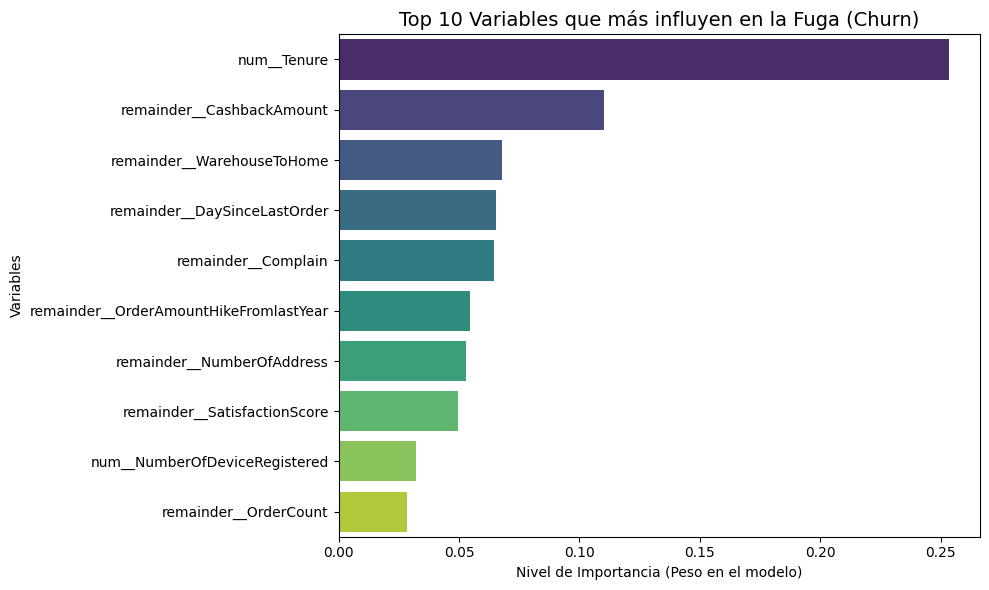

In [31]:
# 1. Extraemos las importancias matemáticas del modelo Random Forest
importancias = rf_model.feature_importances_

# 2. Las unimos con los nombres de tus 24 columnas
df_importancias = pd.DataFrame({
    'Variable': X_train_clean.columns,
    'Importancia': importancias
})

# 3. Ordenamos de mayor a menor importancia
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# 4. Graficamos el Top 10 de variables más críticas
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(10), palette='viridis')
plt.title('Top 10 Variables que más influyen en la Fuga (Churn)', fontsize=14)
plt.xlabel('Nivel de Importancia (Peso en el modelo)')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()